In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
from Bio.Data import CodonTable

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter
from dna_features_viewer import GraphicFeature, GraphicRecord

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv").dropna(subset='Lineage')

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants_WHO_catalog.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

mixed_samples = df_trust_patients.query("F2 > 0.03").SampleID.unique()

def get_RvID_from_gff(attr_str):
    """
    Parse the attributes column of a GFF line.
    Returns a dict of key:value pairs.
    """
    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['ID'].split('-')[-1]


def get_geneName_from_gff(attr_str):

    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['Name']

F2_max = 0.03

df_who_variants = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
genes_with_awR_mutations = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

cc_df = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/drug_CC.csv")

rrs
rrl
rrf


# Get TBTypeR Assignments for Culture Samples

Use the major lineage proportion instead of F2.

In [273]:
df_tbtyper_culture = pd.read_csv("~/MtbLongitudinalDiversity/direct_sputum/culture_TBtypeR_results.csv")

df_tbtyper_culture['SampleID'] = df_tbtyper_culture['sample_id'].str.split('.').str[0]

df_tbtyper_culture['mix_phylotypes'] = df_tbtyper_culture.groupby('sample_id')['mix_phylotype'].transform(lambda x: ','.join(x))
df_tbtyper_culture['mix_props'] = df_tbtyper_culture.groupby('sample_id')['mix_prop'].transform(lambda x: ','.join(np.array(x).astype(str)))
df_tbtyper_culture['Major_Lineage_Prop'] = df_tbtyper_culture.groupby('sample_id')['mix_prop'].transform(lambda x: np.max(x))

df_tbtyper_culture = df_tbtyper_culture.drop_duplicates(subset='SampleID')
df_tbtyper_culture = df_tbtyper_culture.merge(df_trust_patients[['pid', 'SampleID', 'Original_ID', 'Sampling_Week']])
# df_tbtyper_DS_culture_matched = pd.read_csv("~/MtbLongitudinalDiversity/direct_sputum/TBTypeR_ full_results_matched_culture_DS.csv")

def lineage_shannon_entropy(props_string):
    
    props = np.array(props_string.split(',')).astype(float)
    
    return -np.sum([p * np.log2(p) for p in props])

df_tbtyper_culture['Mix_Props_Shannon_Entropy'] = df_tbtyper_culture['mix_props'].apply(lineage_shannon_entropy)

df_tbtyper_culture['MixedInfect'] = (df_tbtyper_culture['n_phy'] > 1).astype(int)

df_tbtyper_culture['Log_Mix_Props_Shannon_Entropy'] = np.log10(df_tbtyper_culture['Mix_Props_Shannon_Entropy'])
df_tbtyper_culture.loc[df_tbtyper_culture['Mix_Props_Shannon_Entropy']==0, 'Log_Mix_Props_Shannon_Entropy'] = 0

In [3]:
df_tbtyper_culture.MixedInfect.value_counts()

MixedInfect
0    732
1     35
Name: count, dtype: int64

<Axes: xlabel='Mix_Props_Shannon_Entropy', ylabel='Count'>

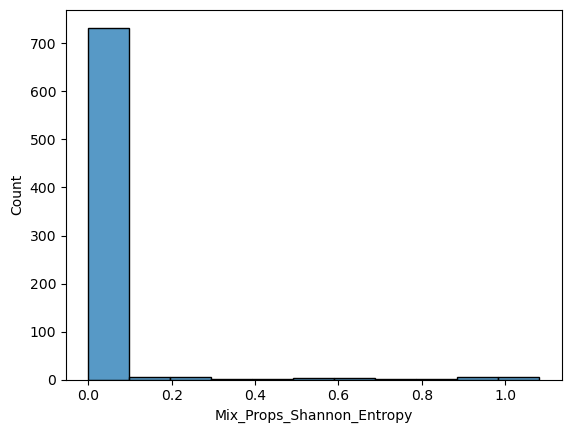

In [95]:
sns.histplot(data=df_tbtyper_culture,
             x='Mix_Props_Shannon_Entropy',
             # log=True
            )

<Axes: xlabel='Mix_Props_Shannon_Entropy', ylabel='Count'>

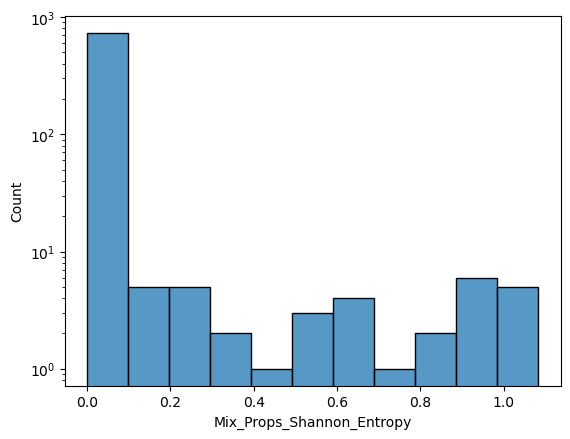

In [96]:
sns.histplot(data=df_tbtyper_culture,
             x='Mix_Props_Shannon_Entropy',
             log=True
            )

In [4]:
df_baseline_samples = df_trust_patients.query("Sampling_Week <= 2").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first')
print(f"{df_baseline_samples.pid.nunique()} pids with baseline samples")

418 pids with baseline samples


In [179]:
df_pids_for_outcomes_model.MixedInfect.value_counts()

MixedInfect
0    374
1     26
Name: count, dtype: int64

# Drug Resistance Mutations in Mixed Infection Samples

In [300]:
isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & drug != 'Ethionamide'")[['SampleID', 'POS', 'REF', 'ALT', 'AF', 'drug', 'confidence', 'variant', 'GENE', 'HGVS_P']].merge(df_tbtyper_culture[['pid', 'SampleID', 'n_phy', 'mix_phylotypes', 'mix_props', 'Sampling_Week', 'Original_ID']].query("n_phy > 1")).drop_duplicates(subset=['SampleID', 'variant']).sort_values('pid')

,SampleID,POS,REF,ALT,AF,drug,confidence,variant,GENE,HGVS_P,pid,n_phy,mix_phylotypes,mix_props,Sampling_Week,Original_ID
3,MFS-577,1674048,G,A,0.92,Isoniazid,1) Assoc w R,inhA_c.-154G>A,fabG1,p.Leu203Leu,T0116,2,"2.2.M1.1,4.3.3","0.9496,0.0504",1,S0116-01
2,MFS-313,1674481,T,G,0.56,Isoniazid,2) Assoc w R - Interim,inhA_p.Ser94Ala,inhA,p.Ser94Ala,T0305,2,"4.3.2.1,2.2.M1.1","0.5757,0.4243",1,S0305-01
0,MFS-198,781687,A,G,0.94,Streptomycin,1) Assoc w R,rpsL_p.Lys43Arg,rpsL,p.Lys43Arg,T0322,2,"4.1.1.3,2.2.M1.1","0.9332,0.0668",1,S0322-01
1,MFS-198,2155167,GC,TG,0.96,Isoniazid,1) Assoc w R,katG_p.Ser315Thr,katG,p.Ser315Thr,T0322,2,"4.1.1.3,2.2.M1.1","0.9332,0.0668",1,S0322-01
4,MFS-705,781822,A,G,0.85,Streptomycin,1) Assoc w R,rpsL_p.Lys88Arg,rpsL,p.Lys88Arg,T0441,2,"2.2.M1.1,4.1.2.1","0.8492,0.1508",1,S0441-01
5,MFS-705,1673425,C,T,0.84,Isoniazid,1) Assoc w R,inhA_c.-777C>T,Rv1482c-fabG1,NaN,T0441,2,"2.2.M1.1,4.1.2.1","0.8492,0.1508",1,S0441-01
6,MFS-822,781822,A,G,0.98,Streptomycin,1) Assoc w R,rpsL_p.Lys88Arg,rpsL,p.Lys88Arg,T0441,2,"2.2.M1.1,4.1.2.1","0.9675,0.0325",8,S0441-08
7,MFS-822,1673425,C,T,0.96,Isoniazid,1) Assoc w R,inhA_c.-777C>T,Rv1482c-fabG1,NaN,T0441,2,"2.2.M1.1,4.1.2.1","0.9675,0.0325",8,S0441-08


In [303]:
df_tbtyper_culture.query("pid=='T0305'")

,sample_id,n_phy,likelihood,error_rate,p_val_perm,p_val_wsrst,abs_diff,mix_index,mix_node,mix_phylotype,...,SampleID,mix_phylotypes,mix_props,Major_Lineage_Prop,pid,Original_ID,Sampling_Week,Mix_Props_Shannon_Entropy,MixedInfect,Log_Mix_Props_Shannon_Entropy
169,MFS-313.filtered.vcf.gz,2,-5957.554287,0.000618,0.0,2.324528e-62,156.1424,1,9,4.3.2.1,...,MFS-313,"4.3.2.1,2.2.M1.1","0.5757,0.4243",0.5757,T0305,S0305-01,1,0.983402,1,-0.007269
170,MFS-314.filtered.vcf.gz,1,-5033.045663,0.000679,0.0,-1.000000e+00,inf,1,9,4.3.2.1,...,MFS-314,4.3.2.1,1.0,1.0000,T0305,S0305-08,8,-0.000000,0,0.000000


In [304]:
isolate_variants.query("SampleID=='MFS-314' & variant=='inhA_p.Ser94Ala'")

,SampleID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,pid
8109,MFS-314,1674481,T,G,PASS,8939.0,False,1.0,271.0,33.0,...,0.0,0.0,missense_variant,inhA,c.280T>G,p.Ser94Ala,inhA_p.Ser94Ala,Ethionamide,2) Assoc w R - Interim,T0305
8110,MFS-314,1674481,T,G,PASS,8939.0,False,1.0,271.0,33.0,...,0.0,0.0,missense_variant,inhA,c.280T>G,p.Ser94Ala,inhA_p.Ser94Ala,Isoniazid,2) Assoc w R - Interim,T0305


# Associate TCC and composite outcomes with TBTypeR information

In [5]:
import sys
sys.path.append(os.path.join(os.getcwd(), "scripts"))
from epi_utils import *

In [241]:
cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'adherence_rate_by_observed',
            'high_lung_involvement',
            'INH_R_mut'
           ]

PLI_thresh = 20

# try these first, as they were required for the full TCC model
# stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'HIV_CD4', 'high_lung_involvement', 'smoked_substance_use', 'screen_sex']
stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'HIV_CD4', 'high_lung_involvement', 'underweight']

non_linear_term_variables = []

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv").query("pid in @df_trust_patients.pid")

df_TCC = df_imputed_TCC.query("imp_num==0").reset_index(drop=True)
df_imputed_TCC = df_imputed_TCC.query("imp_num > 0").reset_index(drop=True)

CNN_results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

# this includes TTP, PK AUC, and CXR data merged in
df_processed_patients = pd.read_csv(f"{TRUST_data_dir}/20251126_cleaned_patient_outcomes_data.csv")

df_pids_for_outcomes_model, TRUST_phenos, df_pred_combined = read_combine_all_TRUST_data(df_processed_patients, 
                                                                                         {'RIF': 'lineage_amino_acid',
                                                                                          'INH': 'lineage_amino_acid',
                                                                                          'EMB': 'lineage_amino_acid',
                                                                                          'PZA': 'amino_acid'}, 
                                                                                         CNN_results_dir,
                                                                                         F2_thresh=1, 
                                                                                         baseline_only=True
                                                                                        )

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_longitudinal_pids.pid").drop_duplicates(subset='pid').reset_index(drop=True)
# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_baseline_samples.pid").drop_duplicates(subset='pid').reset_index(drop=True)

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @pids_with_same_lineage_and_low_F2").drop_duplicates(subset='pid').reset_index(drop=True)
# df_pids_for_outcomes_model = df_pids_for_outcomes_model.drop_duplicates(subset='pid').reset_index(drop=True)

df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_baseline_samples.pid & Sampling_Week <= 2").merge(df_tbtyper_culture, on=['pid', 'SampleID'])
df_pids_for_outcomes_model['inh_resistant'] = (df_pids_for_outcomes_model['pid'].isin(TRUST_phenos.query("INH_lower_bound >= 0.1").pid.values)).astype(int)

df_pids_for_outcomes_model['underweight'] = (df_pids_for_outcomes_model['bl_bmi'] < 18).astype(int)
df_pids_for_outcomes_model['High_TTP'] = (df_pids_for_outcomes_model['TTP_baseline'] > 300).astype(int)

# add mixed infection determination from tbtyper
df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_baseline_samples[['pid', 'SampleID']].merge(df_tbtyper_culture[['SampleID', 'MixedInfect', 'n_phy', 'Mix_Props_Shannon_Entropy', 'Log_Mix_Props_Shannon_Entropy']]))

del df_pids_for_outcomes_model['predicted_PLI']
df_PLI = pd.read_csv("~/MtbQuantCNN/analysis/TRUST/processed_data/PLI_Timika_predictions.csv")
df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_PLI.query("Outlier==0 & View=='1B'").sort_values(['pid', 'View']).drop_duplicates('pid', keep='first'), on='pid', how='left')

df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'] = df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'].replace(2, np.nan)

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("Sampling_Week <= 2")
df_pids_for_outcomes_model = df_pids_for_outcomes_model.sort_values(['pid', 'Original_ID']).drop_duplicates(subset='pid', keep='first').reset_index(drop=True)

df_pids_for_outcomes_model['MixedInfect'] = (df_pids_for_outcomes_model['F2'] > 0.01).astype(int)

samples_with_INH_R_mutations = isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & drug=='Isoniazid'").SampleID.unique()

df_pids_for_outcomes_model['INH_R_mut'] = df_pids_for_outcomes_model['SampleID'].isin(samples_with_INH_R_mutations).astype(int)

len(df_pids_for_outcomes_model), df_pids_for_outcomes_model.pid.nunique()

406 patients with uncontaminated WGS samples
400 patients with uncontaminated WGS samples taken in the first 2 weeks

8 patients: ['T0402' 'T0206' 'T0128' 'T0042' 'T0404' 'T0032' 'T0403' 'T0170'] have multiple sequences at the same timepoint
403 patients have MICs for RIF
403 patients have MICs for INH
403 patients have MICs for EMB
282 patients have MICs for PZA
398 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 400 pids
Found predicted INH MICs for 400 pids
Found predicted EMB MICs for 400 pids
Found predicted PZA MICs for 400 pids
400 patients have predicted MICs


(400, 400)

In [240]:
df_pids_for_outcomes_model.INH_R_mut.value_counts()

INH_R_mut
0    386
1     14
Name: count, dtype: int64

In [209]:
df_pids_for_outcomes_model['MixedInfect'].value_counts()

MixedInfect
1    252
0    148
Name: count, dtype: int64

In [201]:
df_tbtyper_culture.n_phy.value_counts()

n_phy
1    732
2     32
3      3
Name: count, dtype: int64

In [202]:
df_bacterial_burden.groupby('MixedInfect')['bl_hiv'].mean()

MixedInfect
0    0.273458
1    0.346154
Name: bl_hiv, dtype: float64

In [55]:
table = pd.crosstab(df_bacterial_burden["MixedInfect"], df_bacterial_burden["HIV_CD4"])
chi2, p, dof, expected = st.chi2_contingency(table)

print(p)
table

0.5884394346425097


HIV_CD4,0.0,1.0,2.0
MixedInfect,,,
0,271,62,36
1,17,5,4


In [56]:
table = pd.crosstab(df_bacterial_burden["MixedInfect"], df_bacterial_burden["bl_hiv"])
chi2, p, dof, expected = st.chi2_contingency(table)

print(p)
table

0.5663282212458762


bl_hiv,0.0,1.0
MixedInfect,,
0,271,102
1,17,9


In [57]:
expected

array([[269.23308271, 103.76691729],
       [ 18.76691729,   7.23308271]])

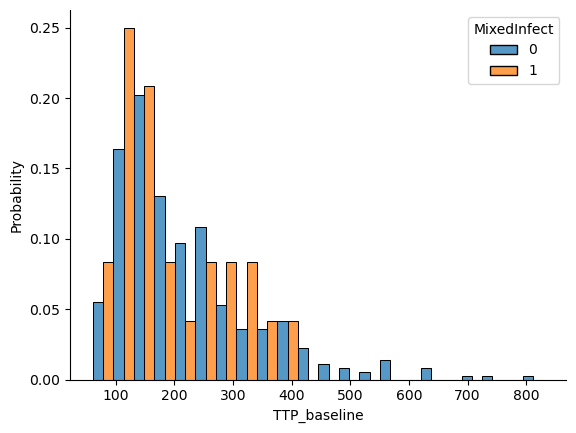

In [38]:
sns.histplot(data=df_bacterial_burden,
             x='TTP_baseline',
             hue='MixedInfect',
             multiple='dodge',
             stat='probability',
             common_norm=False
            )

sns.despine()

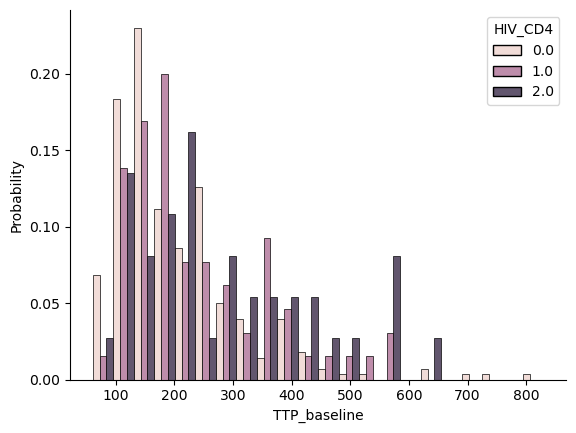

In [43]:
sns.histplot(data=df_bacterial_burden,
             x='TTP_baseline',
             hue='HIV_CD4',
             multiple='dodge',
             stat='probability',
             common_norm=False
            )

sns.despine()

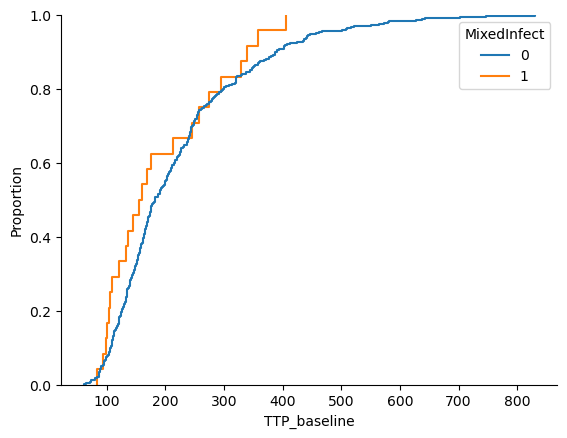

In [39]:
sns.ecdfplot(data=df_bacterial_burden,
             x='TTP_baseline',
             hue='MixedInfect',
            )

sns.despine()

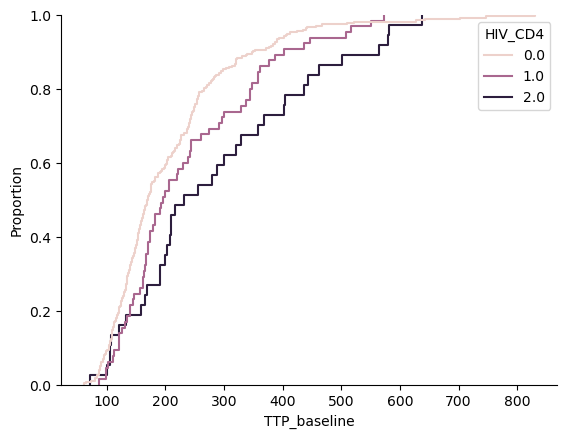

In [44]:
sns.ecdfplot(data=df_bacterial_burden,
             x='TTP_baseline',
             hue='HIV_CD4',
            )

sns.despine()

In [254]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': f'PLI > {PLI_thresh}%',
               'Not_Lineage_2': 'Not Lineage 2',
               'NumVar': '# of low-AF Segregating Sites',
               'NumVar1': '# of low-AF Sites at Baseline',
               'ChangeSites': '# of low-AF Sites with a Change',
               'underweight': 'BMI < 18',
               'adherence_rate_by_observed': 'Tx Adherence',
               'SASE1': 'Site-Averaged Shannon Entropy at Baseline',
               'cxr_cavity_chest_radiograph_1': 'Cavitation',
               'predicted_PLI': 'Predicted % Lung Involvement',
               'Mix_Props_Shannon_Entropy': 'Lineage Shannon Entropy',
               'MixedInfect': 'Mixed Infection',
               'n_phy': 'Number of Lineages',
               'Log_Mix_Props_Shannon_Entropy': 'Shannon Entropy of Lineage Distribution',
               'INH_R_mut': 'Isoniazid Resistance Mutation'
             }

In [225]:
cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'adherence_rate_by_observed',
            'high_lung_involvement',
           ]


In [242]:
mix_col = 'MixedInfect'
# mix_col = 'n_phy'
# mix_col = 'Log_Mix_Props_Shannon_Entropy'

df_test_results, df_model_processed, cph_models_imputations = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                  df_imputed_TCC,
                                                                                                  cols_lst + [mix_col],
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                 MIC_type = 'none',
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True
                                                                                                 )

df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

print(len(df_violating_covariates.query("p <= 0.05")))

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'
df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    348 total pids
9


In [243]:
df_violating_covariates.query("p <= 0.01").covariate.value_counts()

Series([], Name: count, dtype: int64)

In [248]:
df_test_results.query("pval <= 0.05").sort_values('pval')[['covariate', 'pval', 'HR_TCC_assoc', 'HR_TCC_assoc_lower', 'HR_TCC_assoc_upper']]

KeyError: "['HR_TCC_assoc', 'HR_TCC_assoc_lower', 'HR_TCC_assoc_upper'] not in index"

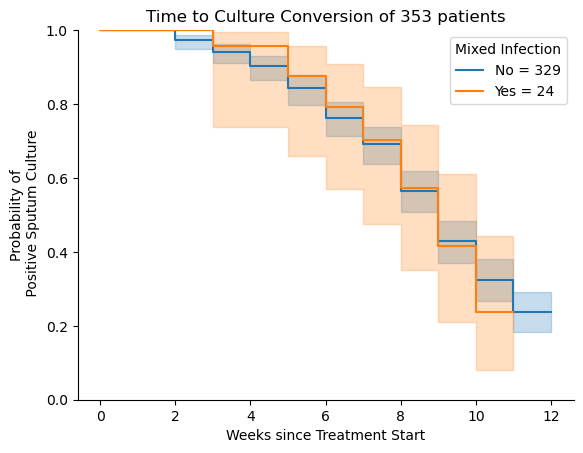

In [128]:
df_check_stratify_vars = df_pids_for_outcomes_model.merge(df_TCC, on='pid')

categorical_cols = ['MixedInfect']
labels_lst = ['Mixed Infection']

legend_name_dict = dict(zip(categorical_cols, labels_lst))

df_logrank_pvalues = pd.DataFrame(columns = ['covariate', 'pval', 'TCC_ratio']).set_index('covariate')

for variable in categorical_cols:
    
    fig, ax = plt.subplots()
    
    df_single_variable = df_check_stratify_vars.dropna(subset=variable)
    df_single_variable[variable] = df_single_variable[variable].astype(int)
    
    if variable == 'HIV_CD4':
        legend_marker_dict = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200 cells/mm\u00B3', 2: 'HIV+, CD4 < 200 cells/mm\u00B3'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))
    # elif variable == 'Lineage 2':
    #     legend_marker_dict = {1: 'L1', 2: 'L2', 3: 'L3', 4: 'L4'}
    #     color_dict = {1: "#DF83AC", 2: "#7098CB", 3: "#815D9F", 4: "#E76956"}
    else:
        legend_marker_dict = {0: 'No', 1: 'Yes'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

    # sort so that 0 is plotted before 1
    for group in np.sort(df_single_variable[variable].unique()):
        
        df_single_group = df_single_variable.query(f"{variable}==@group")
            
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
            
        kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{legend_marker_dict[group]} = {len(df_single_group)}")

        if variable != 'HIV_CD4':
            plt.legend(title=legend_name_dict[variable])

    # HIV with high CD4 and HIV-negative are not significantly different, so just compare HIV with low CD4 to the other 2 groups
    if variable == 'HIV_CD4':
        
        # do them separately for each of the two HIV groups relative to the no HIV group
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_High_CD4', :] = [logRank_test_results.p_value,
                                                     df_single_variable.query(f"{variable}==1")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                                    ]
        
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==2")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==2")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_Low_CD4', :] = [logRank_test_results.p_value, 
                                                    df_single_variable.query(f"{variable}==2")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                                   ]
        
    else:
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc[variable, :] = [logRank_test_results.p_value, 
                                               df_single_variable.query(f"{variable}==1")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                              ]

    # print(f"{legend_name_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")
    plt.ylim(0, 1)

    sns.despine()
    plt.title(f"Time to Culture Conversion of {df_single_variable.pid.nunique()} patients")
    plt.ylabel("Probability of\n Positive Sputum Culture") #
    plt.xlabel("Weeks since Treatment Start")
    sns.despine()
            
#     if variable in stratify_covariates:
#         # plt.show()
#         plt.savefig(f"/home/sak0914/MtbLongitudinalDiversity/results/figures/TCC/KM_estimate_stratified_{legend_name_dict[variable]}.svg", bbox_inches='tight')
#     else:
#         plt.close()
    
# df_logrank_pvalues.to_csv("/home/sak0914/MtbLongitudinalDiversity/results/TCC/KM_logRank_test_pvalues.csv")

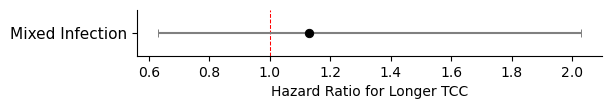

In [120]:
forest_plot(df_test_results, 
            df_test_results.sort_values(['pval', 'HR_TCC_assoc'], ascending=[True, False]).covariate.values, 
            labels_dict, 
            val_col='HR_TCC_assoc', 
            alpha=0.05, 
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            # saveName="../results/figures/TCC/forest_plot.svg"
           )

In [111]:
lineage_mixing_metric = 'F2'

df_test_results_diversity, _, _ = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                              df_pred_combined, 
                                                                TRUST_phenos,
                                                              df_imputed_TCC,
                                                           [lineage_mixing_metric] + stratify_covariates,#cols_lst + [lineage_mixing_metric],
                                                              event_col = 'culture_convert',
                                                              time_col = 'TCC',
                                                              invert_OR=True,
                                                              stratify_variables=stratify_covariates,
                                                             binary_lineage=True
                                                             )

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'

df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    353 total pids


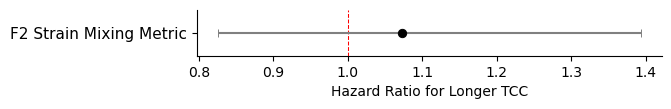

In [112]:
forest_plot(df_test_results_diversity, 
            df_test_results_diversity.sort_values(['pval', 'HR_TCC_assoc'], ascending=[True, False]).covariate.values, 
            labels_dict, 
            val_col='HR_TCC_assoc', 
            alpha=0.05, 
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            # saveName="../results/figures/TCC/forest_plot.svg"
           )

# Composite Unfavorable Outcomes

In [245]:
# to_studyto_treatment_outcome column. 
# Other descriptions in to_studyto_other_treatment_outcome
# additional comments in to_comments_treatment_outcome
treatment_outcome_dict = {1: 'cure',
                          2: 'complete',
                          3: 'defaulted', # typically they stopped taking treatment entirely, not just interruption. May have been doctor-recommended, like due to liver injury or something
                          4: 'failure',
                          5: 'extension',
                          6: 'death',
                          7: 'transferred',
                          8: 'lost_fu',
                          9: 'other'
                        }

# esp_reason_end_of_study_parti column
# Other descriptions in esp_reasonoth_end_of_study_parti
esp_dict = {1: 'complete', # completed all study requirements
            2: 'inappropriate', # should not have been included in the study
            3: 'withdrew',
            4: 'failure', # includes both groups 4 and 5 in treatment_outcome_dict, meaning the patient was culture positive at month 5 or tx was extended
            5: 'relapse',
            6: 'moved', # moved/transferred out,
            7: 'lost_fu',
            8: 'death',
            9: 'other'
            }

cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'adherence_rate_by_observed',
            'high_lung_involvement',
            'INH_R_mut',
            # 'predicted_PLI',
            # 'cxr_cavity_chest_radiograph_1',
            # 'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
           ]

tb_deaths_only = True

# try these first, as they were required for the full TCC model
stratify_covariates = []

MIC_type = 'none'

df_tx_outcomes_full = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv")
df_tx_outcomes = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv").query("pid in @df_pids_for_outcomes_model.pid")

df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'event'] = 0
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'censor_date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['esp_date_end_of_study_parti']
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['time_in_trial']

df_tx_outcomes['weeks'] = df_tx_outcomes['date'] / 7
df_tx_outcomes['months'] = df_tx_outcomes['date'] / 30

print(f"Maximum event date: {df_tx_outcomes.weeks.max()} weeks")

Maximum event date: 99.0 weeks


In [256]:
df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                  df_pred_combined,
                                                                                   TRUST_phenos,
                                                                                  df_tx_outcomes,
                                                                                  cols_lst,
                                                                                  event_col = 'event',
                                                                                  time_col = 'date',
                                                                                    MIC_type = 'none',
                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                  invert_OR=False,
                                                                                  stratify_variables=stratify_covariates,
                                                                                 binary_lineage=True,
                                                                                PLI_thresh=PLI_thresh
                                                                                 )


# convert to HR per 10 years
OR_col = 'OR'
df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

df_violating_covariates = []

for model_idx in range(len(cph_model)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)
print(len(df_violating_covariates.query("p <= 0.05")))

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

base_model_LL = cph_model.log_likelihood_

    Censored 6 patients with non-TB deaths
    373 total pids
0
Proportional hazard assumption looks okay.
    AIC: 312.4095089212309
    Concordance Index: 0.6932539682539682
    Log Likelihood: -141.20475446061545


In [247]:
df_test_results.query("pval <= 0.05").sort_values('pval')

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
10,HIV_Low_CD4,0.355112,1.42634,0.156474,1.20095,0.529178,1,0.02324,3.323271,1.177955,9.37568


In [257]:
mix_col = 'MixedInfect'

df_test_results_diversity, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                              df_pred_combined, 
                                                                TRUST_phenos,
                                                              df_tx_outcomes,
                                                           cols_lst + [mix_col],
                                                              event_col = 'event',
                                                              time_col = 'date',
                                                                                          MIC_type='none',
                                                              tb_deaths_only=tb_deaths_only,
                                                              invert_OR=False,
                                                              stratify_variables=stratify_covariates,
                                                             binary_lineage=True,
                                                                                          PLI_thresh=PLI_thresh
                                                             )

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

OR_col = 'OR'

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

diversity_metric_continuous_LL = cph_model.log_likelihood_

# # scale the odds ratio to be for an increase of 5 variable sites
# if not binarize:
#     scale_factor = 10
#     df_test_results_diversity.loc[df_test_results_diversity['covariate']==diversity_metric, [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate']==diversity_metric, [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor
#     df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

print(f"Final: {df_model_processed.pid.nunique()} pids")

    Censored 6 patients with non-TB deaths
    373 total pids
Proportional hazard assumption looks okay.
    AIC: 314.2533974735216
    Concordance Index: 0.6927248677248677
    Log Likelihood: -141.1266987367608
Final: 373 pids


In [258]:
df_test_results_diversity.query("pval <= 0.05")

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
10,HIV_Low_CD4,0.355112,1.42634,0.156474,1.20095,0.529178,1,0.02324,3.323271,1.177955,9.37568


posx and posy should be finite values
posx and posy should be finite values


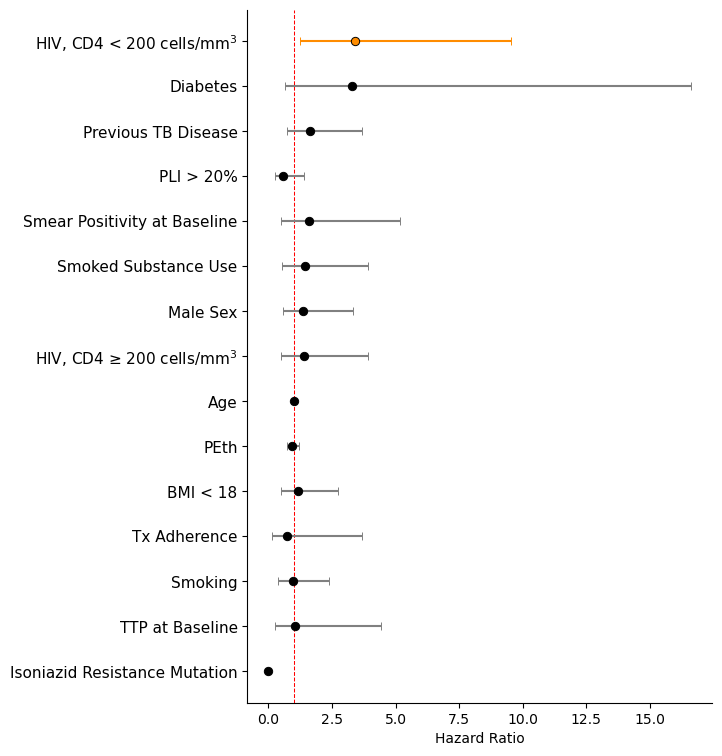

In [255]:
forest_plot(df_test_results_diversity, 
            df_test_results_diversity.sort_values(['pval', 'OR'], ascending=[True, False]).covariate.values, 
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            # saveName="../results/figures/TCC/forest_plot.svg"
           )

362
26
MixedInfect: p = 0.9315326952169136


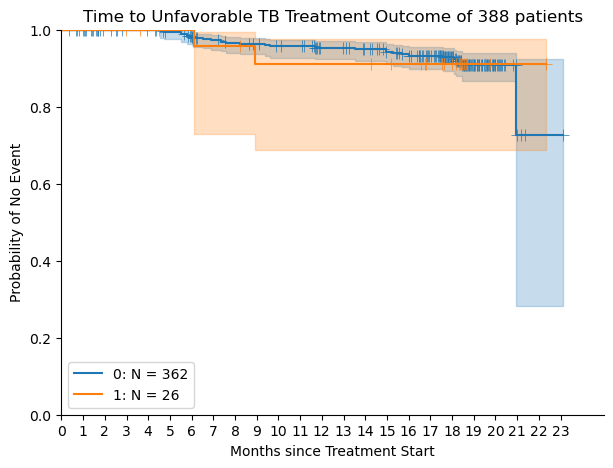

In [205]:
df_KM_plot = df_pids_for_outcomes_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

stratify_col = 'MixedInfect'

label_dict = {
    "Q1": r"$25^{\mathrm{th}}$",
    "Q2": r"$50^{\mathrm{th}}$",
    "Q3": r"$75^{\mathrm{th}}$",
    "Q4": r"$100^{\mathrm{th}}$"
}

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))
    # group_name = label_dict[group]

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               # color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               label=f"{group}: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0, 1)

logRank_test_results = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington")
print(f"{stratify_col}: p = {logRank_test_results.p_value}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles.svg", bbox_inches='tight')

In [173]:
df_pids_for_outcomes_model[['pid', 'F2', 'MixedInfect']].query("F2 <= 0.03 & MixedInfect==1")

,pid,F2,MixedInfect
26,T0030,0.014411,1
196,T0224,0.012533,1
221,T0253,0.023156,1
369,T0440,0.010406,1
388,T0465,0.022986,1


In [175]:
df_pids_for_outcomes_model.query("MixedInfect==0").F2.max()

0.0258794881094243

In [178]:
df_pids_for_outcomes_model.query("MixedInfect==0").query("F2 > 0.01")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,failed,mix_phylotypes,mix_props,Major_Lineage_Prop,Mix_Props_Shannon_Entropy,MixedInfect,Log_Mix_Props_Shannon_Entropy,inh_resistant,underweight,High_TTP
0,T0001,S0001-01,MFS-331,MFS-331_lib58943,NaN,NaN,1.0,437.07,1.00,0.9887,...,False,4.3.2.1,1.0,1.0,-0.0,0,0.0,0,0,1
3,T0004,S0004-01,MFS-1,MFS-1_lib45531,NaN,NaN,1.0,317.21,0.99,0.9903,...,False,2.2.M1.1,1.0,1.0,-0.0,0,0.0,0,1,0
4,T0005,S0005-01,MFS-332,MFS-332_lib58944,NaN,NaN,1.0,348.59,0.99,0.9890,...,False,2.2.M1.1,1.0,1.0,-0.0,0,0.0,0,1,0
7,T0009,S0009-01,MFS-334,MFS-334_lib58946,NaN,NaN,1.0,394.04,1.00,0.9896,...,False,4.1.2.1,1.0,1.0,-0.0,0,0.0,0,0,0
9,T0011,S0011-01,MFS-514,MFS-514_lib64066,NaN,NaN,1.0,307.26,0.99,0.9905,...,False,2.2.M1.1,1.0,1.0,-0.0,0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,T0470,S0470-01,MFS-858,MFS-858_lib73354,NaN,NaN,1.0,373.00,0.99,0.9866,...,False,2.2.M2.5,1.0,1.0,-0.0,0,0.0,0,1,0
394,T0471,S0471-01,MFS-860,MFS-860_lib73356,NaN,NaN,1.0,371.19,0.99,0.9841,...,False,2.2.M1.1,1.0,1.0,-0.0,0,0.0,0,1,1
396,T0474,S0474-01,MFS-864,MFS-864_lib73360,NaN,NaN,1.0,570.01,0.99,0.9870,...,False,2.2.M4.8,1.0,1.0,-0.0,0,0.0,0,0,0
397,T0475,S0475-01,MFS-866,MFS-866_lib73362,NaN,NaN,1.0,478.76,0.99,0.9863,...,False,2.2.M1.1,1.0,1.0,-0.0,0,0.0,0,0,1
